# Non-linear Magnetostatics

_______

## 1) Problem definition

We aim to compute the norm of the flux density $B=|\vec{B}|$ in a ferromagnetic torus of radius $R$. A coil with $N$ turns carrying a current $i$ is wound around the core. 

<center><img src="images/torus.png"
width="300"/></center>



### Nonlinear material law

The magnetic field $\vec{H}$ ($A/m$) inside the ferromagnetic core reads

$$ \vec{H} = \frac{\vec{B}}{\mu(B)}, $$

with $\mu$ its material permeability ($H/m$). After fitting with measurements, the permeability can be written as

$$ \mu(B) = \frac{1}{100 + 10\exp(1.8 B^2)}. $$



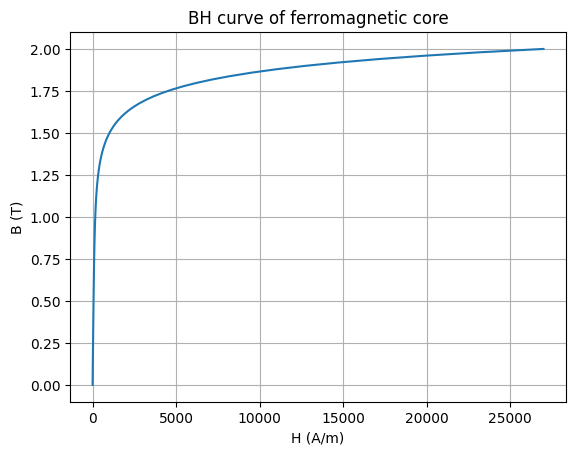

In [76]:
import numpy as np

# Define the permeability model
def mu(B):
    """ Magnetic permeability of ferromagnetic core """
    return 1/(100 + 10*np.exp(1.8*B**2)) 

# Also the derivative, we'll need it later
def dmu_db(B):
    """ Derivative of mu(B) """
    return -20*1.8*B*np.exp(1.8*B**2) * mu(B)**2

import matplotlib.pyplot as plt

# Plot the BH curve
b = np.linspace(0,2,100)
plt.plot(b/mu(b), b); plt.xlabel("H (A/m)"); plt.ylabel("B (T)")
plt.grid(); plt.title("BH curve of ferromagnetic core")
plt.show()

### Constitutive equation

Ampère theorem gives the implicit expression of $B$ with respect to $i$
$$\mathcal S (B, i) =  0 $$

with 

$$\mathcal S (B, i) = \frac{B}{\mu(B)} - \frac{N i}{2\pi R}$$

In [77]:
# Define the state equation

def S(B, i):
    """ State equation linking B and i """
    N = 100   # number of turns
    R = 5e-2  # radius of toroidal core (m)
    return B/mu(B) - N*i/(2*np.pi*R)

# and its derivative (we'll need it later)

def dS_dB(B):
    """ Derivative of state equation """
    return  (mu(B) - B * dmu_db(B)) / mu(B) ** 2

We aim to solve this nonlinear state equation with **fixed-point** algorithm. For the purpose of analysis, we need a **reference solution** $B_{ref}$, computed with the root finder of the standard library `scipy`.

In [78]:
from scipy.optimize import fsolve

def Bref(i, b0 = 0):
    """ Return the reference flux density value """
    return fsolve(lambda B : S(B, i), b0, fprime = lambda B : dS_dB(B), xtol = 1e-14)[0]

# Example
I_example = 1 # A
Bref_example = Bref(I_example)
print(f"{Bref_example = :.6f} T")

Bref_example = 1.237246 T


________

## 2) Fixed-point

### Algorithm
Solving $\mathcal S(B,i_0) = 0$ for a fixed $i_0$ is equivalent to find the fixed-point of 
$$ \mathcal F(B) = B + A \mathcal S(B,i_0),$$

with $A\neq 0$, *i.e.*, find $B$ such that $F(B) = B$.

In [79]:
def F(B, i, A):
    """ Fixed-point function """
    return B + A * S(B, i)

# We'll need the derivative later
def dF_dB(B, A):
    """ Derivative of F """
    return  1 + A * dS_dB(B)

 Following the expression of $\mathcal F$, the update of the fixed-point algorithm is simply

$$B_{n+1} = \mathcal F(B_{n}). $$

In [80]:
def fixedPoint(F, B0 = 0, maxit = 100, tol = 1e-6):
    """ Fixed-point algorithm """
    BList = [B0]
    for _ in range(maxit):
        BList.append( F(BList[-1]) )   # keeps track of all iterations
         # stop criterion : |F(B) - B| = |B(n) - B(n-1)| < tol
        if abs(BList[-1] - BList[-2]) < tol :
            break
    return np.array(BList)

# Example
A_example = -1e-3
F_example = lambda B : F(B, i=I_example, A=A_example)
B_example = fixedPoint(F_example, B0 = 0)

We can plot the algorithm steps

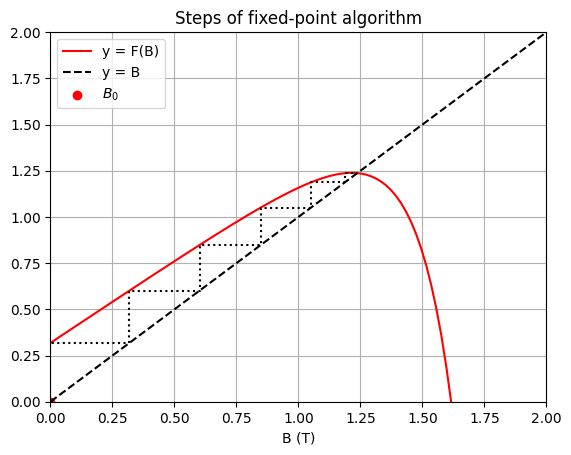

In [81]:
import matplotlib.pyplot as plt

def plot_fixedPoint(F, BList):
    """ Plot the different steps of the fixed-point algorithm """
    B = np.linspace(0, 2, 100)
    plt.plot(B, F(B), "r", label = "y = F(B)")
    plt.plot(B, B,'--k', label = "y = B")
    Bplot, Fplot = np.repeat(BList,2), np.repeat(F(BList),2)
    plt.plot(Bplot, np.hstack([BList[0], Fplot[:-1]]), "k:" )
    plt.xlabel("B (T)"); plt.grid()
    plt.scatter(BList[0],BList[0], color = "r", label = "$B_0$")
    plt.axis([0,2,0,2])
    plt.title(f"Steps of fixed-point algorithm")
    plt.legend(loc = 'upper left')

# Example
plot_fixedPoint(F_example, B_example)

### Convergence

**Reminder** : the sequence $(u_n)$ converges to $u^*$ with order $q \leq 1$ at rate $\mu$ when
$$ \lim_{n\rightarrow \infty} \frac{|u_{n+1}-u^*|}{ |u_n-u^*|^q } = \mu. $$

In particular we call the convergence
- **Sublinear** if it converges but  $\lim_{n\rightarrow \infty} \frac{|u_{n+1}-u^*|}{ |u_n-u^*| } = 1 $
- **Linear** if it converges and  $\lim_{n\rightarrow \infty} \frac{|u_{n+1}-u^*|}{ |u_n-u^*| } = \mu  \in (0, 1) $
- **Superlinear** if it converges and $\lim_{n\rightarrow \infty} \frac{|u_{n+1}-u^*|}{ |u_n-u^*| } = 0 $
- **Quadratic** if it converges and $\lim_{n\rightarrow \infty} \frac{|u_{n+1}-u^*|}{ |u_n-u^*|^2 } = \mu \in (0, +\infty) $

|F'(Bref)| = 0.12397


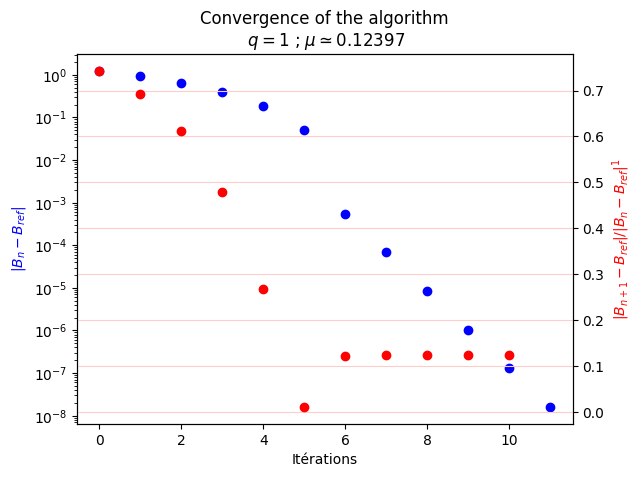

In [82]:
def plot_convergence(values, q = 1):
    """ Plot convergence to 0 of a list of values """
    ax1 = plt.semilogy(np.abs(values), "bo") 
    plt.ylabel("$|B_n - B_{ref}|$", color = 'b')
    plt.xlabel('Itérations')
    ax2 = plt.gca().twinx()
    mu = np.abs(values[1:]) / np.abs(values[:-1])**q
    ax2.plot(mu, 'ro')
    plt.ylabel(f'$|B_{{n+1}} - B_{{ref}}| / |B_{{n}} - B_{{ref}}|^{q}$', color = 'r')
    plt.grid(color = [1,0.8,0.8])
    plt.title(f"Convergence of the algorithm\n ${q = }$ ; $\\mu \\simeq {mu[-1] :.5f}$ ")

# Example
print(f"|F'(Bref)| = {abs(dF_dB(Bref_example, A_example)) :.5f}")
plot_convergence(B_example - Bref(I_example), q = 1)

 Note that the (local) convergence of this algorithm depends on $||\mathcal F'(B_{ref})||$ :
- $||\mathcal F'(B_{ref})|| = 0 $ leads to **superlinear** convergence
- $||\mathcal F'(B_{ref})|| \in (0, 1)$ leads to **linear** convergence
- $||\mathcal F'(B_{ref})|| = 1 $, then the algorithm **does not converge** in general, or with a sublinear rate.
- $||\mathcal F'(B_{ref})|| > 1$, then the fixed-point $B_{ref}$ is not attractive so the algorithm **cannot converge**.

By adjusting $A$ value we can change $||\mathcal F'(B_{ref})||$ and explore the different behaviors.

In [83]:
from ipywidgets import interact
import ipywidgets as widgets

@interact(A=widgets.FloatSlider(min=-5e-3, max=1e-3, step=1e-4, value=-0.001),
          i=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1),
          B0=widgets.FloatSlider(min=0, max=2, step=0.1, value=0))
def explore_fixedPoint(A, i, B0):
    """ Plot interactively the behavior of the fixed-step algorithm """
    myBref = Bref(i)
    myF = lambda B : F(B, i=i, A= A)
    myBlist = fixedPoint(myF, B0 = B0)
    plt.subplots(1,2, figsize=(9,4))
    plt.subplot(1,2,1)
    plot_fixedPoint(myF, myBlist)
    myBref = Bref(i)
    plt.title(f"Steps of fixed-point algorithm\n $B_{{ref}} = {myBref :.3f}$ T ; $F'(B_{{ref}}) = {dF_dB(myBref,A):.5f}$")
    plt.subplot(1,2,2)
    plot_convergence(myBlist - myBref, q = 1)  
    plt.tight_layout()
    plt.show()  

interactive(children=(FloatSlider(value=-0.001, description='A', max=0.001, min=-0.005, step=0.0001), FloatSli…

_____

## 3) Newton method

### a) Special kind of fixed-point algorithm

Newton method can be seen as an optimal fixed point algorithm, ensuring $||\mathcal F'(B_{ref})|| = 0 $  when it converges. So that, $A$ has to take a very specific value :

$$ \mathcal F'(B_{ref}) = I_d + A \mathcal S'(B_{ref},i_0) = 0 \Rightarrow A = - (\mathcal S'(B_{ref},i_0))^{-1}$$

Of course $B_{ref}$ is unknown, so we simply use $A(B_n) = - (S'(B_n,i_0))^{-1}$, leading to the update :

$$ B_{n+1} = B_n - (\mathcal S'(B_n,i_0))^{-1} \mathcal S(B_n, i_0)  $$

and hope for the best concerning the convergence.  Note that this time, $A$ is not a constant anymore and depends on $B_n$.  Here, $A$ is scalar, but can also be a matrix or a general operator.
If the algorithm converges, then we can show that the order of convergence is **quadratic** in general, which is quite fast (not always though : what if $\mathcal S'$ is not invertible?).

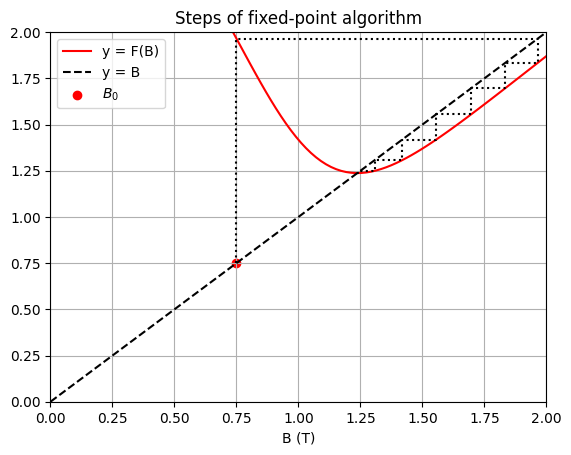

In [84]:
def F_newton(B, i = I_example):
    return B - (dS_dB(B))**(-1) * S(B,i)

B_Newton = fixedPoint(F_newton, B0 = 0.75)
plot_fixedPoint(F_newton, B_Newton)


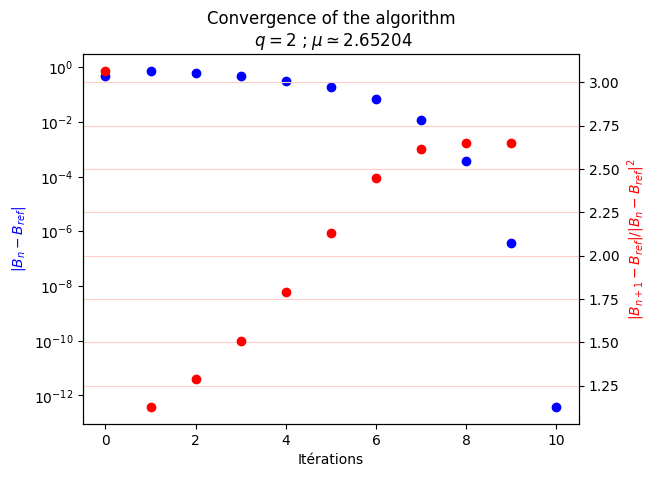

In [85]:
plot_convergence(B_Newton - Bref_example, q = 2)

In [ ]:
@interact(i=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1),
          B0=widgets.FloatSlider(min=0, max=2, step=0.1, value=0))
def explore_Newton(i, B0):
    """ Plot interactively the behavior of the Newton algorithm """
    myBref = Bref(i)
    myF = lambda B : F_newton(B, i=i)
    myBlist = fixedPoint(myF, B0 = B0)
    plt.subplots(1,2, figsize=(9,4))
    plt.subplot(1,2,1)
    plot_fixedPoint(myF, myBlist)
    myBref = Bref(i)
    plt.title(f"Steps of fixed-point Newton algorithm\n $B_{{ref}} = {myBref :.3f}$ T ; $F'(B_{{ref}}) = 0$")
    plt.subplot(1,2,2)
    plot_convergence(myBlist - myBref, q = 2)  
    plt.tight_layout()
    plt.show()  

interactive(children=(FloatSlider(value=1.0, description='i', max=10.0, min=0.1), FloatSlider(value=0.0, descr…

The algorithm is not always stable !! It can explose for high values of $i$, and depends on the starting point ; but we can improve its stability.

### b) Special kind of descent algorithm

We can also solve $\mathcal S(B) = 0$ by applying a **descent algorithm** to minimize 
$$ f(B) = (\mathcal S(B))^2 $$

We can prove that $d(B)$, defined as

$$ d(B) = (\mathcal S'(B))^{-1} \mathcal S(B) \propto - f'(B)$$

is a  **descent direction**. We can plot the algorithm steps.


In [90]:
def plot_descent(S2, BList):
    """ Plot the different steps of the fixed-point algorithm """
    B = np.linspace(0, 2, 100)
    plt.plot(B, S2(B), "r", label = "y = S²(B)")
    plt.plot(BList, S2(BList), "k:*" )
    plt.xlabel("B (T)"); plt.grid()
    plt.scatter(BList[0], S2(BList[0]), color = "r", label = "$B_0$")
    plt.axis([0,2,0,1.2 * S2(B[0])])
    plt.title(f"Steps of descent algorithm")
    plt.legend(loc = 'best')

Since $d(B)$ is a descent direction, we have for $\alpha >0$ sufficiently small, 

$$ f(B + \alpha d(B) ) < f(B) $$

Therefore, one can apply a **line search** before the update to ensure convergence, *i.e.*, finding an appropriate $\alpha$, satisfying for instance Armijo's condition for $s\in [0,1)$:

$$f(B + \alpha d) < ( 1 - 2 s \alpha ) f(B) $$

In [91]:
def newton(residual, dresidual, B0,
           alpha = 0.5, s = 0.1, maxit_linesearch = 10,   # linesearch
           maxit = 100, rtol = 1e-8, atol = 1e-8   # stop criterion
           ):
     """ Newton method with Armijo's linesearch"""
     
     res2 = lambda B : residual(B)**2
     B = [B0]
     res0 = residual(B[0])
     k = 0 
     while abs(residual(B[-1])) > atol \
           and abs(residual(B[-1])/res0) > rtol \
           and k < maxit:
          
        # Descent direction
        d = - dresidual(B[-1]) ** (-1) * residual(B[-1]) ;  

        # Line search (Armijo backtracking)
        i = 0
        res2B = res2(B[-1])
        while res2(B[-1] + alpha ** i * d) >= ( 1 - 2*s*alpha ** i ) * res2B:
            if i>maxit_linesearch: 
                raise Exception("Linesearch has failed after {maxit_linesearch} iterations.")
            i += 1

        B.append(B[-1] +  alpha ** i * d)
        k += 1
        
     return np.array(B)


Let's apply it to our problem

In [ ]:
@interact(i=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1),
          B0=widgets.FloatSlider(min=0, max=2, step=0.1, value=0))
def explore_Newton_linesearch(i, B0):
    """ Plot interactively the behavior of the Newton algorithm with line search"""
    myBref = Bref(i)
    residual = lambda B : S(B, i=i)
    dresidual = lambda B : dS_dB(B)
    myBlist = newton(residual, dresidual, B0)
    plt.subplots(1,2, figsize=(9,4))
    plt.subplot(1,2,1)
    plot_descent(lambda B: residual(B)**2, myBlist)
    myBref = Bref(i)
    plt.title(f"Steps of descent Newton algorithm\n $B_{{ref}} = {myBref :.3f}$ T")
    plt.subplot(1,2,2)
    plot_convergence(myBlist - myBref, q = 2)  
    plt.tight_layout()
    plt.show()  

interactive(children=(FloatSlider(value=1.0, description='i', max=10.0, min=0.1), FloatSlider(value=0.0, descr…